# 使用 U-Net 进行图像分割（Image Segmentation with U-Net）

欢迎学习第三周最后一个作业！你将搭建 U-Net，为自动驾驶场景图片中的每一个像素预测类别。

目标检测用矩形框定位物体；语义分割给每个像素赋予类别。下图中汽车与行人分别对应不同颜色的 Mask：

![原作业：语义分割](images/carseg.png)

本文件按照 `Image_segmentation_Unet_v2.ipynb` 的章节、三个练习和 40 轮训练流程翻译改编，代码全部使用 PyTorch。完成后，你应能解释普通 CNN 与 U-Net 的区别，实现编码块、解码块和完整 U-Net，并使用逐像素交叉熵训练。

目录：1 工具 → 2 加载与配对数据 → 3 U-Net（结构、练习 1 编码块、练习 2 解码块、练习 3 完整模型、损失和数据展示）→ 4 训练、创建预测 Mask、曲线、结果展示 → 总结。

## 1 - 工具（Packages）

使用安装了 torch、numpy、Pillow、IPython 的内核。图片、Mask 和训练曲线全部由 PIL 生成静态 PNG，不导入 Matplotlib，避免此前的绘图后端卡顿。

PyTorch 使用 NCHW：输入 `(N,3,H,W)`，模型 logits `(N,C,H,W)`，整数 Mask `(N,H,W)`。

In [1]:
import os
os.environ.setdefault("MKL_THREADING_LAYER","SEQUENTIAL")
from pathlib import Path
from io import BytesIO
import time,random
import torch
from torch import nn
from torch.utils.data import Dataset,DataLoader,random_split
import numpy as np
from PIL import Image,ImageDraw
from IPython.display import display,Image as PNGImage

SEED=42
random.seed(SEED);np.random.seed(SEED);torch.manual_seed(SEED)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
def find_assignment():
    name="Image Segmentation Unet"
    for base in (Path.cwd(),*Path.cwd().parents):
        for p in (base,base/name,base/"C4 - Convolutional Neural Networks/Week 3"/name):
            if (p/"Image_segmentation_Unet_v2.ipynb").is_file():return p
    raise FileNotFoundError("请从本项目内启动 Jupyter。")
ASSIGNMENT_DIR=find_assignment()
print("设备:",device,"作业目录:",ASSIGNMENT_DIR,flush=True)

def show_pil(image):
    with BytesIO() as stream:
        image.save(stream,format="PNG")
        display(PNGImage(data=stream.getvalue()))

设备: cuda 作业目录: D:\ACMpractice\pytorch\learn_pytorch_WuEnDa\C4 - Convolutional Neural Networks\Week 3\Image Segmentation Unet


## 2 - 加载并配对数据（Load and Split the Data）

原作业目录为 `data/CameraRGB/` 和 `data/CameraMask/`。RGB 图片与 Mask 必须按**相同文件名**配对，不能只分别排序后假定一一对应。本地当前没有该数据目录，所以下面会提示并跳过真实训练；网络结构和绘图仍可从头运行。

### 2.1 - 分开未标注图片和 Mask

课程数据的 Mask 是 RGB PNG，但三个通道编码同一个类别值；原版使用通道最大值转换为单通道类别编号。这里保留这个处理，并验证标签范围为 0～22。

### 2.2 - 预处理数据

RGB 图片转换为 `[0,1]` 的 float32。Mask 使用最近邻缩放，保持整数类别；不能除以 255，也不能使用双线性插值产生不存在的小数类别。

In [2]:
IMAGE_DIR=ASSIGNMENT_DIR/"data/CameraRGB"
MASK_DIR=ASSIGNMENT_DIR/"data/CameraMask"
NUM_CLASSES=23
IMG_HEIGHT,IMG_WIDTH=96,128

def paired_files(image_dir,mask_dir):
    images={p.name:p for p in image_dir.glob("*.png")}
    masks={p.name:p for p in mask_dir.glob("*.png")}
    missing_masks=sorted(images.keys()-masks.keys())
    missing_images=sorted(masks.keys()-images.keys())
    if missing_masks or missing_images:
        raise ValueError(f"图片/Mask 文件名不匹配：缺 Mask {missing_masks[:3]}，缺图片 {missing_images[:3]}")
    return [(images[name],masks[name]) for name in sorted(images)]

DATA_READY=IMAGE_DIR.is_dir() and MASK_DIR.is_dir()
pairs=paired_files(IMAGE_DIR,MASK_DIR) if DATA_READY else []
if pairs:
    print("配对样本数:",len(pairs),"示例:",pairs[0])
else:
    DATA_READY=False
    print("缺少 CARLA 数据:",IMAGE_DIR,"和",MASK_DIR,flush=True)
    print("将跳过真实训练，继续进行结构与绘图检查。",flush=True)

class CarlaSegmentationDataset(Dataset):
    def __init__(self,pairs):self.pairs=pairs
    def __len__(self):return len(self.pairs)
    def __getitem__(self,index):
        image_path,mask_path=self.pairs[index]
        with Image.open(image_path) as src:
            image=src.convert("RGB").resize((IMG_WIDTH,IMG_HEIGHT),Image.Resampling.BILINEAR)
        with Image.open(mask_path) as src:
            mask_rgb=np.array(src.convert("RGB").resize((IMG_WIDTH,IMG_HEIGHT),Image.Resampling.NEAREST))
        mask=mask_rgb.max(axis=-1).astype(np.int64)
        if mask.min()<0 or mask.max()>=NUM_CLASSES:
            raise ValueError(f"Mask 类别应在 0~{NUM_CLASSES-1}，实际 {mask.min()}~{mask.max()}")
        image=torch.from_numpy(np.array(image)).permute(2,0,1).float()/255.0
        return image,torch.from_numpy(mask)

def colorize_mask(mask):
    mask=np.asarray(mask,dtype=np.int64)
    colors=np.array([((37*i+30)%256,(79*i+50)%256,(131*i+70)%256) for i in range(NUM_CLASSES)],dtype=np.uint8)
    return Image.fromarray(colors[np.clip(mask,0,NUM_CLASSES-1)])

def tensor_to_image(x):
    return Image.fromarray((x.detach().cpu().permute(1,2,0).clamp(0,1).numpy()*255).astype(np.uint8))

if DATA_READY:
    sample_image,sample_mask=CarlaSegmentationDataset(pairs)[3 if len(pairs)>3 else 0]
    canvas=Image.new("RGB",(IMG_WIDTH*2,IMG_HEIGHT+25),"white")
    canvas.paste(tensor_to_image(sample_image),(0,25));canvas.paste(colorize_mask(sample_mask),(IMG_WIDTH,25))
    ImageDraw.Draw(canvas).text((5,5),"Input Image        True Mask",fill="black")
    show_pil(canvas);canvas.close()

缺少 CARLA 数据: D:\ACMpractice\pytorch\learn_pytorch_WuEnDa\C4 - Convolutional Neural Networks\Week 3\Image Segmentation Unet\data\CameraRGB 和 D:\ACMpractice\pytorch\learn_pytorch_WuEnDa\C4 - Convolutional Neural Networks\Week 3\Image Segmentation Unet\data\CameraMask
将跳过真实训练，继续进行结构与绘图检查。


## 3 - U-Net

U-Net 最初用于医学图像分割。FCN 用卷积替代全连接并上采样，但深层特征经过多次下采样后丢失精细位置。U-Net 使用对称的编码器和解码器，并把编码器对应尺度的特征拼接到解码器，帮助恢复边缘和位置。

### 3.1 - 模型细节

![原作业：U-Net 结构](images/unet.png)

- 编码器降低高宽、增加通道，提取特征。
- 解码器用转置卷积恢复高宽、减少通道。
- Skip connection 在通道维拼接，不是 ResNet 的逐元素相加。
- 最后 1×1 卷积把每个像素映射到 23 个类别分数。

原论文示意图使用不补零卷积并裁剪。本作业代码明确使用 `padding='same'`，因此对应 PyTorch 卷积使用 `padding=1`，同尺度特征可直接拼接。

### 3.2 - 编码器（Downsampling Block）

![原作业：编码器](images/encoder.png)

每个 `conv_block` 包含两个 3×3 Conv + ReLU，可选 Dropout 和 2×2 最大池化。它返回：

- `next_layer`：池化后的结果，送入下一层；
- `skip_connection`：池化前的结果，送给解码器。

### 练习 1 - conv_block

原版函数直接接收张量。PyTorch 先创建模块，再在 `forward` 中接收张量。卷积使用 He/Kaiming 初始化，对应原版 `he_normal`。

In [3]:
def initialize_conv(module):
    if isinstance(module,(nn.Conv2d,nn.ConvTranspose2d)):
        nn.init.kaiming_normal_(module.weight,nonlinearity="relu")
        if module.bias is not None:nn.init.zeros_(module.bias)

class ConvBlock(nn.Module):
    def __init__(self,in_channels,n_filters=32,dropout_prob=0,max_pooling=True):
        super().__init__()
        self.conv1=nn.Conv2d(in_channels,n_filters,3,padding=1)
        self.conv2=nn.Conv2d(n_filters,n_filters,3,padding=1)
        self.relu=nn.ReLU()
        self.dropout=nn.Dropout2d(dropout_prob) if dropout_prob>0 else nn.Identity()
        self.pool=nn.MaxPool2d(2,2) if max_pooling else None
        self.apply(initialize_conv)
    def forward(self,x):
        x=self.relu(self.conv1(x))
        x=self.relu(self.conv2(x))
        x=self.dropout(x)
        skip_connection=x
        next_layer=self.pool(x) if self.pool is not None else x
        return next_layer,skip_connection

def conv_block(in_channels,n_filters=32,dropout_prob=0,max_pooling=True):
    return ConvBlock(in_channels,n_filters,dropout_prob,max_pooling)

block=conv_block(3,32).eval()
with torch.no_grad():next_layer,skip=block(torch.zeros(2,3,96,128))
assert next_layer.shape==(2,32,48,64) and skip.shape==(2,32,96,128)
assert sum(p.numel() for p in block.parameters())==10144
print("练习 1 通过：next",tuple(next_layer.shape),"skip",tuple(skip.shape))

练习 1 通过：next (2, 32, 48, 64) skip (2, 32, 96, 128)


### 3.3 - 解码器（Upsampling Block）

![原作业：解码器](images/decoder.png)

解码块用 3×3 转置卷积、步幅 2 上采样，再与对应编码器特征沿通道维拼接，之后用两个 3×3 卷积融合。

### 练习 2 - upsampling_block

原版 `Conv2DTranspose(..., kernel_size=3, strides=2, padding='same')` 对偶数输入精确翻倍。PyTorch 使用 `padding=1, output_padding=1` 得到相同空间尺寸。若输入形状不是这种规则，函数会明确报告无法拼接。

In [4]:
class UpsamplingBlock(nn.Module):
    def __init__(self,expansive_channels,contractive_channels,n_filters=32):
        super().__init__()
        self.up=nn.ConvTranspose2d(expansive_channels,n_filters,3,stride=2,padding=1,output_padding=1)
        self.conv1=nn.Conv2d(n_filters+contractive_channels,n_filters,3,padding=1)
        self.conv2=nn.Conv2d(n_filters,n_filters,3,padding=1)
        self.relu=nn.ReLU()
        self.apply(initialize_conv)
    def forward(self,expansive_input,contractive_input):
        up=self.up(expansive_input)
        if up.shape[0]!=contractive_input.shape[0] or up.shape[-2:]!=contractive_input.shape[-2:]:
            raise ValueError(f"无法拼接：上采样 {tuple(up.shape)}，捷径 {tuple(contractive_input.shape)}")
        merge=torch.cat([up,contractive_input],dim=1)
        x=self.relu(self.conv1(merge))
        return self.relu(self.conv2(x))

def upsampling_block(expansive_channels,contractive_channels,n_filters=32):
    return UpsamplingBlock(expansive_channels,contractive_channels,n_filters)

upblock=upsampling_block(256,128,32).eval()
with torch.no_grad():out=upblock(torch.zeros(2,256,12,16),torch.zeros(2,128,24,32))
assert out.shape==(2,32,24,32)
print("练习 2 通过：输出",tuple(out.shape))

练习 2 通过：输出 (2, 32, 24, 32)


### 3.4 - 构建完整模型

### 练习 3 - unet_model

编码器通道依次为 32、64、128、256，瓶颈为 512；从第 4 个编码块开始使用 0.3 Dropout，瓶颈不池化。解码器依次恢复为 256、128、64、32 通道，并与相应的池化前特征拼接。

原版在解码器末尾额外使用一个 3×3、32 通道卷积 `conv9`，再用 1×1 卷积输出类别；这里保留这一层。

In [5]:
class UNet(nn.Module):
    def __init__(self,input_channels=3,n_filters=32,n_classes=23):
        super().__init__()
        self.c1=conv_block(input_channels,n_filters)
        self.c2=conv_block(n_filters,n_filters*2)
        self.c3=conv_block(n_filters*2,n_filters*4)
        self.c4=conv_block(n_filters*4,n_filters*8,dropout_prob=.3)
        self.c5=conv_block(n_filters*8,n_filters*16,dropout_prob=.3,max_pooling=False)
        self.u6=upsampling_block(n_filters*16,n_filters*8,n_filters*8)
        self.u7=upsampling_block(n_filters*8,n_filters*4,n_filters*4)
        self.u8=upsampling_block(n_filters*4,n_filters*2,n_filters*2)
        self.u9=upsampling_block(n_filters*2,n_filters,n_filters)
        self.conv9=nn.Conv2d(n_filters,n_filters,3,padding=1)
        self.relu=nn.ReLU()
        self.classifier=nn.Conv2d(n_filters,n_classes,1)
        self.conv9.apply(initialize_conv);self.classifier.apply(initialize_conv)
    def forward(self,x):
        x,s1=self.c1(x);x,s2=self.c2(x);x,s3=self.c3(x);x,s4=self.c4(x)
        x,_=self.c5(x)
        x=self.u6(x,s4);x=self.u7(x,s3);x=self.u8(x,s2);x=self.u9(x,s1)
        return self.classifier(self.relu(self.conv9(x)))

def unet_model(input_size=(3,96,128),n_filters=32,n_classes=23):
    if tuple(input_size)!=(3,96,128):
        raise ValueError("本作业使用 PyTorch 输入形状 (3,96,128)。")
    return UNet(input_size[0],n_filters,n_classes)

unet=unet_model().to(device).eval()
with torch.no_grad():logits=unet(torch.zeros(2,3,96,128,device=device))
assert logits.shape==(2,23,96,128)
print("练习 3 通过：",tuple(logits.shape),"可训练参数:",sum(p.numel() for p in unet.parameters()))

练习 3 通过： (2, 23, 96, 128) 可训练参数: 8640471


### 3.5 - 模型尺寸

输入固定为 `(N,3,96,128)`。四次池化得到 `48×64 → 24×32 → 12×16 → 6×8`，四次上采样再恢复至 `96×128`。输出通道是类别数 23，不必等于输入的 RGB 三通道。

### 3.6 - 损失函数

原版使用 `SparseCategoricalCrossentropy(from_logits=True)`；PyTorch 对应 `CrossEntropyLoss`。模型直接输出 logits，不在末尾添加 Softmax；Mask 是 `(N,H,W)` 的 long 类别编号。

In [6]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(unet.parameters())
dummy_mask=torch.zeros(2,96,128,dtype=torch.long,device=device)
assert torch.isfinite(criterion(logits,dummy_mask))
print("损失检查通过。")

损失检查通过。


### 3.7 - 数据集处理与展示

下面把输入图、真实 Mask、预测 Mask 横向拼接成一张静态 PNG。类别使用固定伪彩色，便于比较；颜色只用于显示，模型学习的是整数类别。

以下为合成显示样本，不是训练数据。


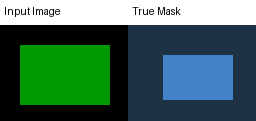

In [7]:
def display_segmentation(image,true_mask,pred_mask=None):
    panels=[tensor_to_image(image),colorize_mask(true_mask)]
    titles=["Input Image","True Mask"]
    if pred_mask is not None:panels.append(colorize_mask(pred_mask));titles.append("Predicted Mask")
    canvas=Image.new("RGB",(IMG_WIDTH*len(panels),IMG_HEIGHT+25),"white")
    draw=ImageDraw.Draw(canvas)
    for i,(panel,title) in enumerate(zip(panels,titles)):
        canvas.paste(panel.resize((IMG_WIDTH,IMG_HEIGHT),Image.Resampling.NEAREST),(i*IMG_WIDTH,25))
        draw.text((i*IMG_WIDTH+4,5),title,fill="black")
    show_pil(canvas);canvas.close()

# 无数据时使用清楚标注的合成样本，只检查显示功能。
if DATA_READY:
    sample_image,sample_mask=CarlaSegmentationDataset(pairs)[0]
else:
    sample_image=torch.zeros(3,96,128);sample_image[1,20:80,20:110]=.6
    sample_mask=torch.zeros(96,128,dtype=torch.long);sample_mask[30:75,35:105]=1
    print("以下为合成显示样本，不是训练数据。")
display_segmentation(sample_image,sample_mask)

## 4 - 训练模型

原版设置 `EPOCHS=40、BATCH_SIZE=32` 且只在训练数据上拟合，没有单独验证集。本版保留 40 轮设置，同时从真实数据中固定划分 80% 训练、20% 验证，便于发现过拟合。缺数据时跳过训练。

每轮和每 10 个 batch 打印进度。`run_epoch` 传优化器时训练，不传时评估；像素准确率按所有像素统计，背景占比很大时可能显得偏高。

In [8]:
def run_epoch(model,loader,criterion,optimizer=None,label="验证"):
    training=optimizer is not None;model.train(training)
    loss_sum,correct,count=0.,0,0;started=time.perf_counter()
    print(f"[{label}] {len(loader)} 个 batch",flush=True)
    with torch.set_grad_enabled(training):
        for step,(x,y) in enumerate(loader,1):
            x,y=x.to(device),y.to(device)
            if training:optimizer.zero_grad(set_to_none=True)
            logits=model(x);loss=criterion(logits,y)
            if not torch.isfinite(loss):raise RuntimeError("损失出现 NaN/Inf。")
            if training:loss.backward();optimizer.step()
            pixels=y.numel();loss_sum+=loss.item()*pixels
            correct+=(logits.argmax(1)==y).sum().item();count+=pixels
            if step==1 or step%10==0 or step==len(loader):
                print(f"[{label}] {step}/{len(loader)}, loss={loss_sum/count:.4f}, {time.perf_counter()-started:.1f}s",flush=True)
    return loss_sum/count,correct/count

def fit(model,train_loader,val_loader,criterion,optimizer,epochs):
    history={k:[] for k in ("loss","accuracy","val_loss","val_accuracy")}
    for epoch in range(1,epochs+1):
        print(f"\nEpoch {epoch}/{epochs}",flush=True)
        loss,acc=run_epoch(model,train_loader,criterion,optimizer,"训练")
        vl,va=run_epoch(model,val_loader,criterion,label="验证")
        for k,v in zip(history,(loss,acc,vl,va)):history[k].append(v)
        print(f"loss={loss:.4f}, accuracy={acc:.3f}, val_loss={vl:.4f}, val_accuracy={va:.3f}",flush=True)
    return history

EPOCHS=40;BATCH_SIZE=32
history=None;train_loader=val_loader=None
if DATA_READY:
    dataset=CarlaSegmentationDataset(pairs)
    n_val=max(1,round(len(dataset)*.2));n_train=len(dataset)-n_val
    if n_train<1:raise ValueError("数据太少，无法划分训练/验证集。")
    train_set,val_set=random_split(dataset,[n_train,n_val],generator=torch.Generator().manual_seed(SEED))
    train_loader=DataLoader(train_set,BATCH_SIZE,shuffle=True,num_workers=0)
    val_loader=DataLoader(val_set,BATCH_SIZE,shuffle=False,num_workers=0)
    unet.train();optimizer=torch.optim.Adam(unet.parameters())
    history=fit(unet,train_loader,val_loader,criterion,optimizer,EPOCHS)
else:
    print("缺少数据，40 轮真实训练已跳过。")

缺少数据，40 轮真实训练已跳过。


### 4.1 - 创建预测 Mask

原版对类别轴 `argmax`。PyTorch 类别轴是 1；函数接收 `(N,C,H,W)`，返回第一张图片的 `(H,W)` 类别 Mask。

In [9]:
def create_mask(pred_logits):
    if pred_logits.ndim!=4:raise ValueError("期望 (N,C,H,W) logits。")
    return pred_logits.argmax(dim=1)[0]
assert create_mask(torch.zeros(1,23,96,128)).shape==(96,128)

### 4.2 - 绘制训练曲线

用 PIL 绘制训练/验证损失和像素准确率。没有真实数据时，用明确标记的演示记录验证绘图能够完成；演示数值不是模型训练结果。

以下仅为绘图自检，不是训练结果。
[绘图] Loss 已生成，开始显示


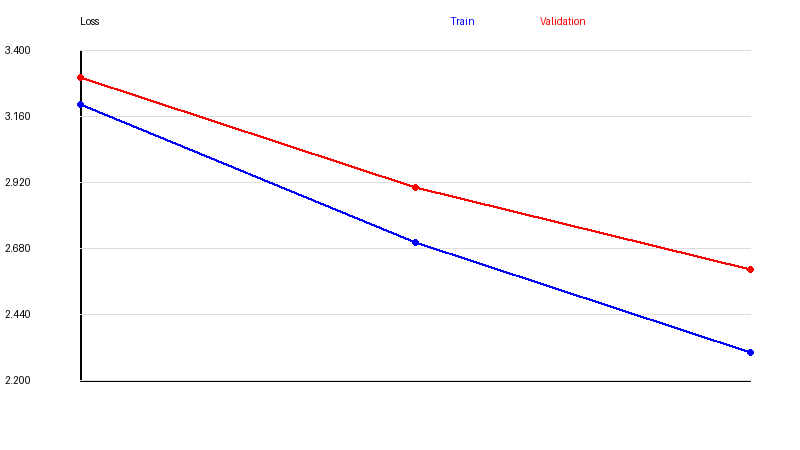

[绘图] Loss 完成
[绘图] Pixel Accuracy 已生成，开始显示


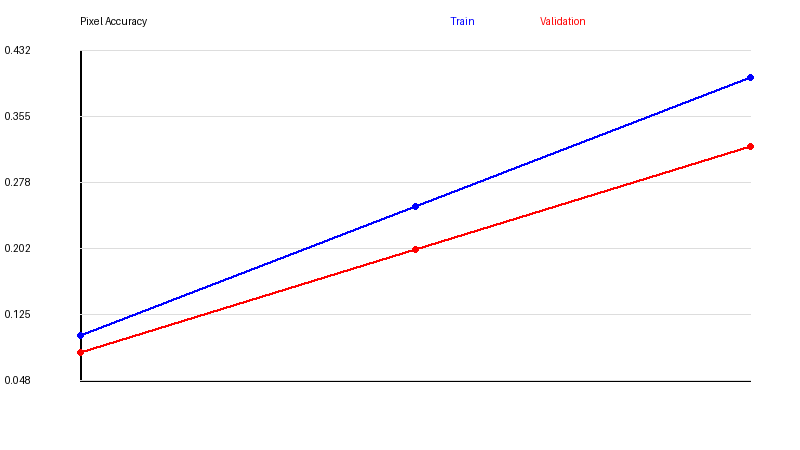

[绘图] Pixel Accuracy 完成


In [10]:
def plot_history(history):
    for key,title in (("loss","Loss"),("accuracy","Pixel Accuracy")):
        train=[float(x) for x in history[key]];val=[float(x) for x in history["val_"+key]]
        values=train+val
        if not values:continue
        canvas=Image.new("RGB",(800,450),"white");draw=ImageDraw.Draw(canvas)
        l,t,r,b=80,50,750,380;lo,hi=min(values),max(values);margin=max((hi-lo)*.1,.01);lo-=margin;hi+=margin
        draw.text((80,15),title,fill="black");draw.text((450,15),"Train",fill="blue");draw.text((540,15),"Validation",fill="red")
        draw.line([(l,t),(l,b),(r,b)],fill="black",width=2)
        for j in range(6):
            y=b-(b-t)*j/5;v=lo+(hi-lo)*j/5;draw.line([(l,y),(r,y)],fill="#dddddd");draw.text((5,y-6),f"{v:.3f}",fill="black")
        n=max(len(train),len(val))
        for series,color in ((train,"blue"),(val,"red")):
            pts=[(l+i/max(n-1,1)*(r-l),b-(v-lo)/(hi-lo)*(b-t)) for i,v in enumerate(series)]
            if len(pts)>1:draw.line(pts,fill=color,width=3)
            for x,y in pts:draw.ellipse((x-3,y-3,x+3,y+3),fill=color)
        print(f"[绘图] {title} 已生成，开始显示",flush=True);show_pil(canvas);canvas.close();print(f"[绘图] {title} 完成",flush=True)

if history is None:
    print("以下仅为绘图自检，不是训练结果。")
    plot_history({"loss":[3.2,2.7,2.3],"val_loss":[3.3,2.9,2.6],
                  "accuracy":[.1,.25,.4],"val_accuracy":[.08,.2,.32]})
else:plot_history(history)

### 4.3 - 显示预测结果

比较输入、真实 Mask 和预测 Mask。模型未训练时不会展示随机预测，以免误认为结果有意义。

In [11]:
def show_predictions(model,dataset,num=1):
    model.eval()
    for i in range(min(num,len(dataset))):
        image,true_mask=dataset[i]
        with torch.no_grad():pred=create_mask(model(image.unsqueeze(0).to(device))).cpu()
        display_segmentation(image,true_mask,pred)

if history is not None:
    show_predictions(unet,val_set,num=min(6,len(val_set)))
else:
    print("缺少训练完成的模型，跳过真实预测 Mask。")

缺少训练完成的模型，跳过真实预测 Mask。


### 总结

- 语义分割为每个像素预测类别，输出为 `(N,C,H,W)`。
- U-Net 的编码器下采样，解码器用转置卷积上采样。
- 编码器特征与解码器特征沿通道拼接，恢复空间细节。
- 多类整数 Mask 使用 CrossEntropyLoss，不需要 one-hot 或提前 Softmax。
- 图片和 Mask 的空间变换必须一致，缩放 Mask 使用最近邻插值。
- 当前目录缺少 CARLA 数据，因此完整训练效果尚未验证；结构、三个练习和 PIL 绘图可直接运行。

直接改编来源：同目录 `Image_segmentation_Unet_v2.ipynb` 及其四张结构图。本文件供 PyTorch 本地学习，不是原 TensorFlow AutoGrader 提交文件。